In [ ]:
import numpy as np
import math
import time
from itertools import combinations


N = 20                #Number city
cities = np.random.rand(N, 2) * 100  

print("=== DATASET 15 CITIES (NEW) ===")
for i, (x, y) in enumerate(cities):
    print(f"City {i}: ({x:.4f}, {y:.4f})")


#FUNCTION DISTANCE
def dist(i, j):
    return math.dist(cities[i], cities[j])

# create matrix distance to push on Held–Karp
dist_matrix = [[dist(i, j) for j in range(N)] for i in range(N)]

# FUNCTION CALCULATE COST TOUR
def tour_cost(tour):
    return sum(dist(tour[i], tour[(i+1) % len(tour)])
               for i in range(len(tour)))


# FUNCTIONS AND TIME MEASUREMENT

def run_algo(name, func):
    print(f"\n=== {name} ===")
    start = time.time()
    cost, tour = func()
    end = time.time()

    print(f"Time: {end - start:.4f} sec")
    print(f"Cost: {cost:.4f}")
    print(f"Tour:", tour)

=== DATASET 15 CITIES (NEW) ===
City 0: (69.6469, 28.6139)
City 1: (22.6851, 55.1315)
City 2: (71.9469, 42.3106)
City 3: (98.0764, 68.4830)
City 4: (48.0932, 39.2118)
City 5: (34.3178, 72.9050)
City 6: (43.8572, 5.9678)
City 7: (39.8044, 73.7995)
City 8: (18.2492, 17.5452)
City 9: (53.1551, 53.1828)
City 10: (63.4401, 84.9432)
City 11: (72.4455, 61.1024)
City 12: (72.2443, 32.2959)
City 13: (36.1789, 22.8263)
City 14: (29.3714, 63.0976)
City 15: (9.2105, 43.3701)
City 16: (43.0863, 49.3685)
City 17: (42.5830, 31.2261)
City 18: (42.6351, 89.3389)
City 19: (94.4160, 50.1837)


In [ ]:
# 2-OPT
def two_opt():
    tour = list(range(N)) + [0]

    def improve(tour):
        best = tour
        improved = True
        while improved:
            improved = False
            for i in range(1, N-1):
                for j in range(i+1, N):
                    new = tour[:i] + tour[i:j+1][::-1] + tour[j+1:]
                    if tour_cost(new) < tour_cost(best):
                        best = new
                        improved = True
            tour = best
        return best

    best_tour = improve(tour)
    return tour_cost(best_tour), best_tour

# 3-OPT
def three_opt():
    tour = list(range(N)) + [0]

    def improve(tour):
        improved = True
        while improved:
            improved = False
            for i in range(1, N-3):
                for j in range(i+1, N-2):
                    for k in range(j+1, N-1):
                        A = tour[:i]
                        B = tour[i:j]
                        C = tour[j:k]
                        D = tour[k:]

                        candidates = [
                            A + B + C + D,
                            A + B[::-1] + C + D,
                            A + B + C[::-1] + D,
                            A + B[::-1] + C[::-1] + D,
                            A + C + B + D
                        ]

                        best = min(candidates, key=tour_cost)
                        if tour_cost(best) < tour_cost(tour):
                            tour = best
                            improved = True
        return tour

    best_tour = improve(tour)
    return tour_cost(best_tour), best_tour

# ====================================
# FULL LIN-KERNIGHAN (Variable k-opt)
# ====================================
def full_lin_kernighan():
    def get_initial_tour():
        unvisited = list(range(1, N))
        current = 0
        tour = [0]
        while unvisited:
            next_node = min(unvisited, key=lambda x: dist_matrix[current][x])
            tour.append(next_node)
            unvisited.remove(next_node)
            current = next_node
        tour.append(0)
        return tour

    current_tour = get_initial_tour()
    best_overall_cost = tour_cost(current_tour)

    candidate_set = []
    for i in range(N):
        line = sorted(range(N), key=lambda x: dist_matrix[i][x])
        candidate_set.append(line[1:11]) 

    def get_node_after(t, tour):
        idx = tour.index(t)
        return tour[idx + 1] if idx < N else tour[1]

    def get_node_before(t, tour):
        idx = tour.index(t)
        return tour[idx - 1] if idx > 0 else tour[N-1]

    def flip_tour(tour, t3, t4, t2, t1):
        new_tour = tour[:]
        i, j = new_tour.index(t2), new_tour.index(t3)
        if i > j: i, j = j, i
        new_tour[i:j+1] = reversed(new_tour[i:j+1])
        return new_tour

    improved = True
    while improved:
        improved = False
        for t1 in range(N):
            for t2 in [get_node_before(t1, current_tour), get_node_after(t1, current_tour)]:
                x1_weight = dist_matrix[t1][t2]
                
                for t3 in candidate_set[t2]:
                    if t3 == t1 or t3 == get_node_before(t2, current_tour) or t3 == get_node_after(t2, current_tour):
                        continue
                    
                    y1_weight = dist_matrix[t2][t3]
                    gain1 = x1_weight - y1_weight
                    
                    if gain1 > 0:
                        for t4 in [get_node_before(t3, current_tour), get_node_after(t3, current_tour)]:
                            if t4 == t1 or t4 == t2: continue
                            gain_final = gain1 + dist_matrix[t3][t4] - dist_matrix[t4][t1]
                            if gain_final > 0:
                                new_tour = flip_tour(current_tour, t3, t4, t2, t1)
                                new_cost = tour_cost(new_tour)
                                if new_cost < best_overall_cost:
                                    best_overall_cost = new_cost
                                    current_tour = new_tour
                                    improved = True
                                    break
                    if improved: break
                if improved: break
            if improved: break

    return best_overall_cost, current_tour

run_algo("2-opt", two_opt)
run_algo("3-opt", three_opt)
run_algo("LK", full_lin_kernighan)



=== 2-opt ===
Time: 0.4988 sec
Cost: 356.6476
Tour: [0, 4, 17, 13, 6, 8, 15, 1, 16, 9, 14, 5, 7, 18, 10, 11, 3, 19, 2, 12, 0]

=== 3-opt ===
Time: 1.1932 sec
Cost: 406.4607
Tour: [0, 12, 2, 11, 3, 10, 9, 16, 4, 17, 13, 6, 8, 15, 1, 14, 5, 7, 18, 19, 0]

=== LK ===
Time: 0.0010 sec
Cost: 341.7773
Tour: [0, 12, 19, 3, 10, 18, 7, 5, 14, 1, 15, 8, 6, 13, 17, 4, 16, 9, 11, 2, 0]


Running 2-opt...
-> Done. Cost: 356.65, Time: 0.4823s

Running 3-opt...
-> Done. Cost: 406.46, Time: 1.1548s

Running Full LK...
-> Done. Cost: 341.78, Time: 0.0010s



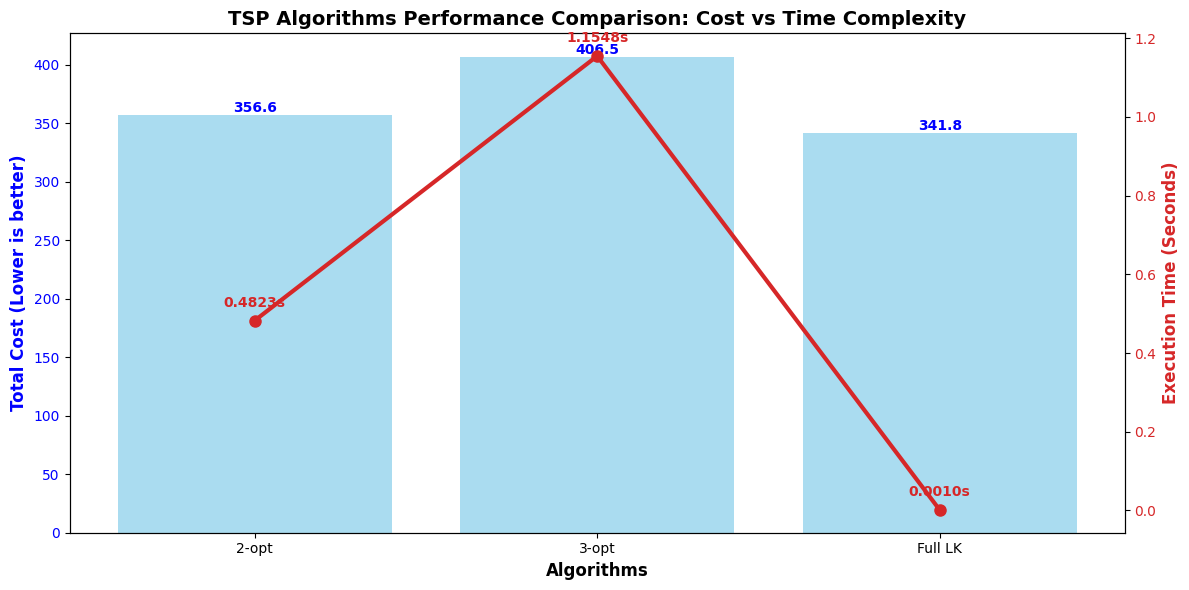

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np

comparison_results = []

def run_algo(name, algo_func):
    print(f"Running {name}...")
    start_time = time.time()
    cost, tour = algo_func()
    end_time = time.time()
    
    execution_time = end_time - start_time
    comparison_results.append({
        "Algorithm": name,
        "Cost": cost,
        "Time": execution_time
    })
    
    print(f"-> Done. Cost: {cost:.2f}, Time: {execution_time:.4f}s\n")

def plot_complexity_comparison():
    names = [r["Algorithm"] for r in comparison_results]
    costs = [r["Cost"] for r in comparison_results]
    times = [r["Time"] for r in comparison_results]

    fig, ax1 = plt.subplots(figsize=(12, 6))

    color_cost = 'skyblue'
    ax1.set_xlabel('Algorithms', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Total Cost (Lower is better)', color='blue', fontsize=12, fontweight='bold')
    bars = ax1.bar(names, costs, color=color_cost, alpha=0.7, label='Tour Cost')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}', ha='center', va='bottom', color='blue', fontweight='bold')

    ax2 = ax1.twinx()  
    color_time = 'tab:red'
    ax2.set_ylabel('Execution Time (Seconds)', color=color_time, fontsize=12, fontweight='bold')
    ax2.plot(names, times, color=color_time, marker='o', markersize=8, linewidth=3, label='Time')
    ax2.tick_params(axis='y', labelcolor=color_time)

    for i, txt in enumerate(times):
        ax2.annotate(f'{txt:.4f}s', (names[i], times[i]), textcoords="offset points", 
                     xytext=(0,10), ha='center', color=color_time, fontweight='bold')

    plt.title('TSP Algorithms Performance Comparison: Cost vs Time Complexity', fontsize=14, fontweight='bold')
    fig.tight_layout()
    
    plt.savefig('comparison_chart.png')
    plt.show()


run_algo("2-opt", two_opt)
run_algo("3-opt", three_opt)
run_algo("Full LK", full_lin_kernighan)

plot_complexity_comparison()